In [2]:
import cv2
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np

In [3]:
class HungrymanWorldEnvironment(gym.Env):
    """This class implements the Hungryman World environment."""

    def __init__(self, environment_type):
        """This method initializes the environment.

        :param str environment_type: - It can take two values: 1. 'deterministic' 2. 'stochastic'
                                       indicating the type of environment."""

        self.environment_type = environment_type

        self.environment_width = 5
        self.environment_height = 5

        self.observation_space = spaces.Discrete(self.environment_width * self.environment_height)
        self.action_space = spaces.Discrete(4)
        self.state_space = [(i, j) for i in range(self.environment_width) for j in range(self.environment_height)]

        self.man_pos = np.asarray([0, 0])
        self.apple_pos = np.asarray([[1, 0], [3, 0], [2, 1], [4, 1], [1, 2], [3, 2], [0, 3]])
        self.cake_pos = np.asarray([4, 4])
        self.spider_pos = np.asarray([[2, 0], [3, 2], [2, 3], [4, 3]])
        self.dog_pos = np.asarray([[0, 2], [3, 3]])

        self.goal_state = np.asarray([4, 4])

        self.man_reward = 0
        self.apple_reward = 5
        self.cake_reward = 10
        self.spider_reward = -5
        self.dog_reward = -10

        reward_map = {(x, y): 0 for x in range(self.environment_width) for y in range(self.environment_height)}
        for pos in self.apple_pos:
            reward_map[tuple(pos)] += self.apple_reward
        for pos in self.spider_pos:
            reward_map[tuple(pos)] += self.spider_reward
        for pos in self.dog_pos:
            reward_map[tuple(pos)] += self.dog_reward
        reward_map[tuple(self.cake_pos)] += self.cake_reward
        self.reward_map = reward_map

    def reset(self):
        """This method resets the man position and returns the state as the observation.

        :returns int observation: -  Integer representing the grid block the man is in.
                 dict info: - A dictionary that can be used to provide additional implementation information."""
        self.man_pos = np.asarray([0, 0])
        return self.man_pos

    def step(self, action):
        """This method implements what happens when the man takes a particular action. It changes the man's
        position (While not allowing it to go out of the environment space.), maps the environment co-ordinates to a
        state, defines the rewards for the various states, and determines when the episode ends.

        :param int action: - Integer in the range 0 to 3 inclusive representing the different actions the man can
        take.

        :returns arr observation: - Array representing the partial observation.
                 int reward: - Integer value that's used to measure the performance of the man.
                 bool terminated: - Boolean describing whether the episode has ended.
                 bool truncated: Boolean describing whether a truncation condition outside the scope of the MDP is
                                 satisfied.
                 dict info: - A dictionary that can be used to provide additional implementation information."""
        
        x, y = self.man_pos

        # Describing the outcomes of the various possible actions.
        if action == 0 and x < self.environment_width - 1:
            self.man_pos[0] += 1  # This action causes the man to go right.
        if action == 1 and x > 0:
            self.man_pos[0] -= 1  # This action causes the man to go left.
        if action == 2 and y < self.environment_height - 1:
            self.man_pos[1] += 1  # This action causes the man to go up.
        if action == 3 and y > 0:
            self.man_pos[1] -= 1  # This action causes the man to go down.

        # self.man_reward += -1
        reward = self.reward_map[self.man_pos[0], self.man_pos[1]]
        self.man_reward += reward

        return reward, np.array_equal(self.goal_state, self.man_pos), self.man_pos

    def render(self, mode='human', plot=False):
        """This method renders the environment.

        :param str mode: 'human' renders to the current display or terminal and returns nothing.
        :param bool plot: Boolean indicating whether we show a plot or not. If False, the method returns a resized NumPy
                     array representation of the environment to be used as the state. If True it plots the environment.

        :returns arr preprocessed_image: Grayscale NumPy array representation of the environment."""

        fig, ax = plt.subplots(figsize=(15, 15))
        ax.set_xlim(0, 5)
        ax.set_ylim(0, 5)

        def plot_image(plot_pos):
            """This is a helper function to render the environment. It checks which objects are in a particular
            position on the grid and renders the appropriate image.

            :param arr plot_pos: Co-ordinates of the grid position which needs to be rendered."""

            # Initially setting every object to not be plotted.
            plot_man, plot_apple, plot_cake, plot_spider, plot_dog = \
                False, False, False, False, False

            # Checking which objects need to be plotted by comparing their positions.
            if np.array_equal(self.man_pos, plot_pos):
                plot_man = True
            if any(np.array_equal(self.apple_pos[i], plot_pos) for i in range(len(self.apple_pos))):
                plot_apple = True
            if np.array_equal(plot_pos, self.cake_pos):
                plot_cake = True
            if any(np.array_equal(self.spider_pos[i], plot_pos) for i in range(len(self.spider_pos))):
                plot_spider = True
            if any(np.array_equal(self.dog_pos[i], plot_pos) for i in range(len(self.dog_pos))):
                plot_dog = True

            # Plot for Man.
            if plot_man and \
                    all(not item for item in
                        [plot_apple, plot_cake, plot_spider, plot_dog]):
                man = AnnotationBbox(OffsetImage(plt.imread('./images/man.png'), zoom=0.20),
                                       np.add(plot_pos, [0.5, 0.5]), frameon=False)
                ax.add_artist(man)

            # Plot for Apple.
            elif plot_apple and \
                    all(not item for item in
                        [plot_man, plot_cake, plot_spider, plot_dog]):
                apple = AnnotationBbox(OffsetImage(plt.imread('./images/apple.png'), zoom=0.20),
                                        np.add(plot_pos, [0.5, 0.5]), frameon=False)
                ax.add_artist(apple)

            # Plot for Cake.
            elif plot_cake and \
                    all(not item for item in
                        [plot_man, plot_apple, plot_spider, plot_dog]):
                cake = AnnotationBbox(OffsetImage(plt.imread('./images/cake.png'), zoom=0.20),
                                      np.add(plot_pos, [0.5, 0.5]), frameon=False)
                ax.add_artist(cake)
                
            # Plot for Spider.
            elif plot_spider and \
                    all(not item for item in
                        [plot_man, plot_apple, plot_cake, plot_dog]):
                spider = AnnotationBbox(OffsetImage(plt.imread('./images/spider.png'), zoom=0.20),
                                        np.add(plot_pos, [0.5, 0.5]), frameon=False)
                ax.add_artist(spider)

            # Plot for Dog.
            elif plot_dog and \
                    all(not item for item in
                        [plot_man, plot_apple, plot_cake, plot_spider]):
                dog = AnnotationBbox(OffsetImage(plt.imread('./images/dog.png'), zoom=0.20),
                                        np.add(plot_pos, [0.5, 0.5]), frameon=False)
                ax.add_artist(dog)

            # Plot for Man and Apple.
            elif all(item for item in [plot_man, plot_apple]) and \
                    all(not item for item in
                        [plot_cake, plot_spider, plot_dog]):
                man_apple = AnnotationBbox(OffsetImage(plt.imread('./images/man_apple.png'), zoom=0.20),
                                              np.add(plot_pos, [0.5, 0.5]), frameon=False)
                ax.add_artist(man_apple)

            # Plot for Man and Spider.
            elif all(item for item in [plot_man, plot_spider]) and \
                    all(not item for item in
                        [plot_apple, plot_cake, plot_dog]):
                man_spider = AnnotationBbox(OffsetImage(plt.imread('./images/man_spider.png'), zoom=0.20),
                                              np.add(plot_pos, [0.5, 0.5]), frameon=False)
                ax.add_artist(man_spider)

            # Plot for Man, Apple and Spider.
            elif all(item for item in [plot_man, plot_apple, plot_spider]) and \
                    all(not item for item in
                        [plot_cake, plot_dog]):
                man_apple_spider = AnnotationBbox(OffsetImage(plt.imread('./images/man_apple_spider.png'),
                                                                 zoom=0.20), np.add(plot_pos, [0.5, 0.5]),
                                                     frameon=False)
                ax.add_artist(man_apple_spider)

            # Plot for Man and Dog.
            elif all(item for item in [plot_man, plot_dog]) and \
                    all(not item for item in
                        [plot_cake, plot_spider, plot_apple]):
                man_dog = AnnotationBbox(OffsetImage(plt.imread('./images/man_dog.png'),
                                                          zoom=0.28), np.add(plot_pos, [0.5, 0.5]), frameon=False)
                ax.add_artist(man_dog)

            # Plot for Apple and Spider.
            elif all(item for item in [plot_apple, plot_spider]) and \
                    all(not item for item in
                        [plot_man, plot_cake, plot_dog]):
                apple_spider = AnnotationBbox(OffsetImage(plt.imread('./images/apple_spider.png'), zoom=0.20),
                                               np.add(plot_pos, [0.5, 0.5]), frameon=False)
                ax.add_artist(apple_spider)

            # Plot for Man and Cake.
            elif all(item for item in [plot_man, plot_cake]) and \
                    all(not item for item in
                        [plot_apple, plot_spider, plot_dog]):
                man_cake = AnnotationBbox(OffsetImage(plt.imread('./images/man_cake.png'), zoom=0.20),
                                              np.add(plot_pos, [0.5, 0.5]), frameon=False)
                ax.add_artist(man_cake)

        coordinates_state_mapping_2 = {}
        for j in range(self.environment_height * self.environment_width):
            coordinates_state_mapping_2[j] = np.asarray(
                [j % self.environment_width, int(np.floor(j / self.environment_width))])

        # Rendering the images for all states.
        for position in coordinates_state_mapping_2:
            plot_image(coordinates_state_mapping_2[position])

        plt.xticks([0, 1, 2, 3, 4])
        plt.yticks([0, 1, 2, 3, 4])
        plt.grid()

        if plot:  # Displaying the plot.
            plt.show()
        else:  # Returning the preprocessed image representation of the environment.
            fig.canvas.draw()
            img = np.array(fig.canvas.renderer.buffer_rgba())[:, :, :3]
            width = 70
            height = 70
            dim = (width, height)
            # noinspection PyUnresolvedReferences
            preprocessed_image = cv2.resize(img, dim, interpolation=cv2.INTER_AREA)
            plt.show()
            return preprocessed_image

In [136]:
def choose_action(Q, state, epsilon, env):
    if np.random.uniform(0, 1) < epsilon:
        return env.action_space.sample()
    else:
        return  max(Q[tuple(state)], key=Q[tuple(state)].get)
    
def sarsa(env, episodes, alpha, discount_factor, epsilon, epsilon_decay, epsilon_min, max_steps):
    Q = {state: {action: 0 for action in range(env.action_space.n)} for state in env.state_space}
    reward_history = []
    epsilon_history = []

    print("Initial Q-Table:")
    for state, actions in Q.items():
        print(state, actions)

    for _ in range(episodes):
        state = env.reset()
        action = choose_action(Q, state, epsilon, env)
        total_reward = 0
        terminated = False
        step = 0

        while not terminated and step < max_steps:
            reward, terminated, next_state = env.step(action)
            next_state = tuple(next_state)
            next_action = None if terminated else choose_action(Q, next_state, epsilon, env)

            # Q-value Update
            Q[tuple(state)][action] += alpha * (reward + (discount_factor * Q[tuple(next_state)][next_action] if next_action else 0) - Q[tuple(state)][action])

            state, action = next_state, next_action
            total_reward += reward
            step += 1

        reward_history.append(total_reward)
        epsilon_history.append(epsilon)
        epsilon = max(epsilon * epsilon_decay, epsilon_min)

    print("\nTrained Q-Table:")
    for state, actions in Q.items():
        print(state, actions)

    return Q, reward_history, epsilon_history


In [176]:
hungryman_world = HungrymanWorldEnvironment(environment_type='deterministic')
episodes = 500
alpha = 0.5
discount_factor = 0.9
epsilon = 1.0
epsilon_decay = 0.99
epsilon_min = 0.1
max_steps = 100

In [169]:
Q, reward_history, epsilon_history = sarsa(hungryman_world, episodes, alpha, discount_factor, epsilon, epsilon_decay, epsilon_min,max_steps)

Initial Q-Table:
(0, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(0, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(0, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(0, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(0, 4) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 4) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 4) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 4) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 4) {0: 0, 1: 0, 2: 0, 3: 0}

Trained Q-Table:
(0, 0) {0: 13.186821436180676, 1: -4.338259482445042e-13, 2: -0.0011057724407997635, 3: -4.937088603176932e-08}
(0, 1) {0: 17.254176725659853, 1: -0.1963080246118128

In [139]:
def evaluate_greedy_policy(env, Q, episodes, max_steps, plot=False):
    reward_history = []

    for i in range(episodes):
        state = env.reset()
        total_reward = 0
        terminated = False
        step = 0

        while not terminated and step < max_steps:
            state = tuple(state)
            action = max(Q[state], key=Q[state].get)
            reward, terminated, state = env.step(action)
            total_reward += reward
            step += 1
            
        if plot:
            print(f"Episode {i}:")
            env.render(plot=True)
        reward_history.append(total_reward)

    return reward_history

Episode 0:


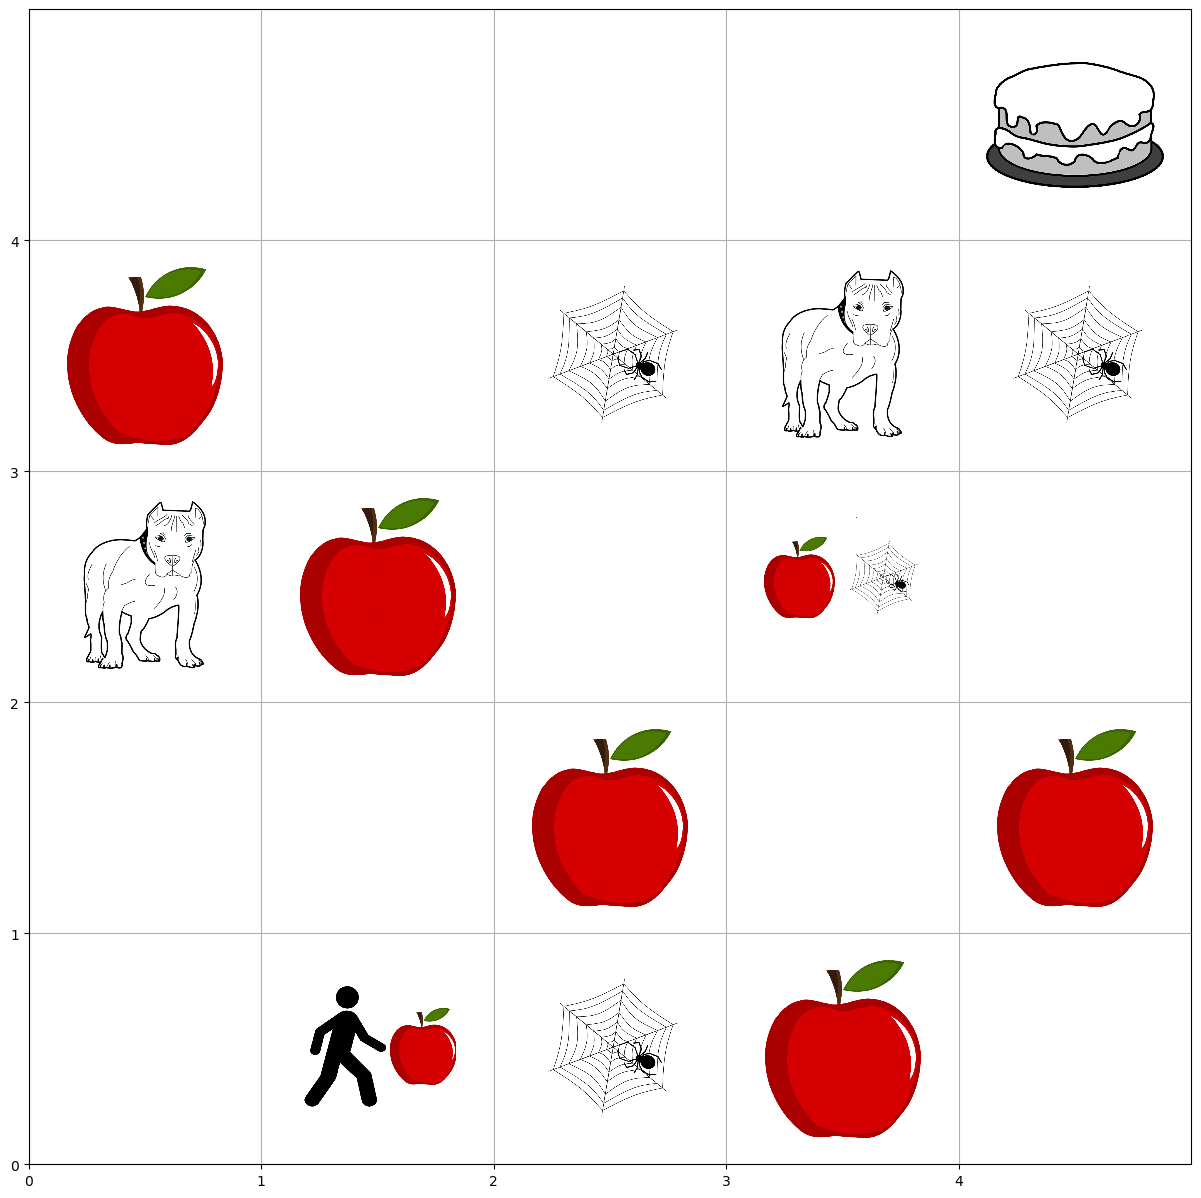

Episode 1:


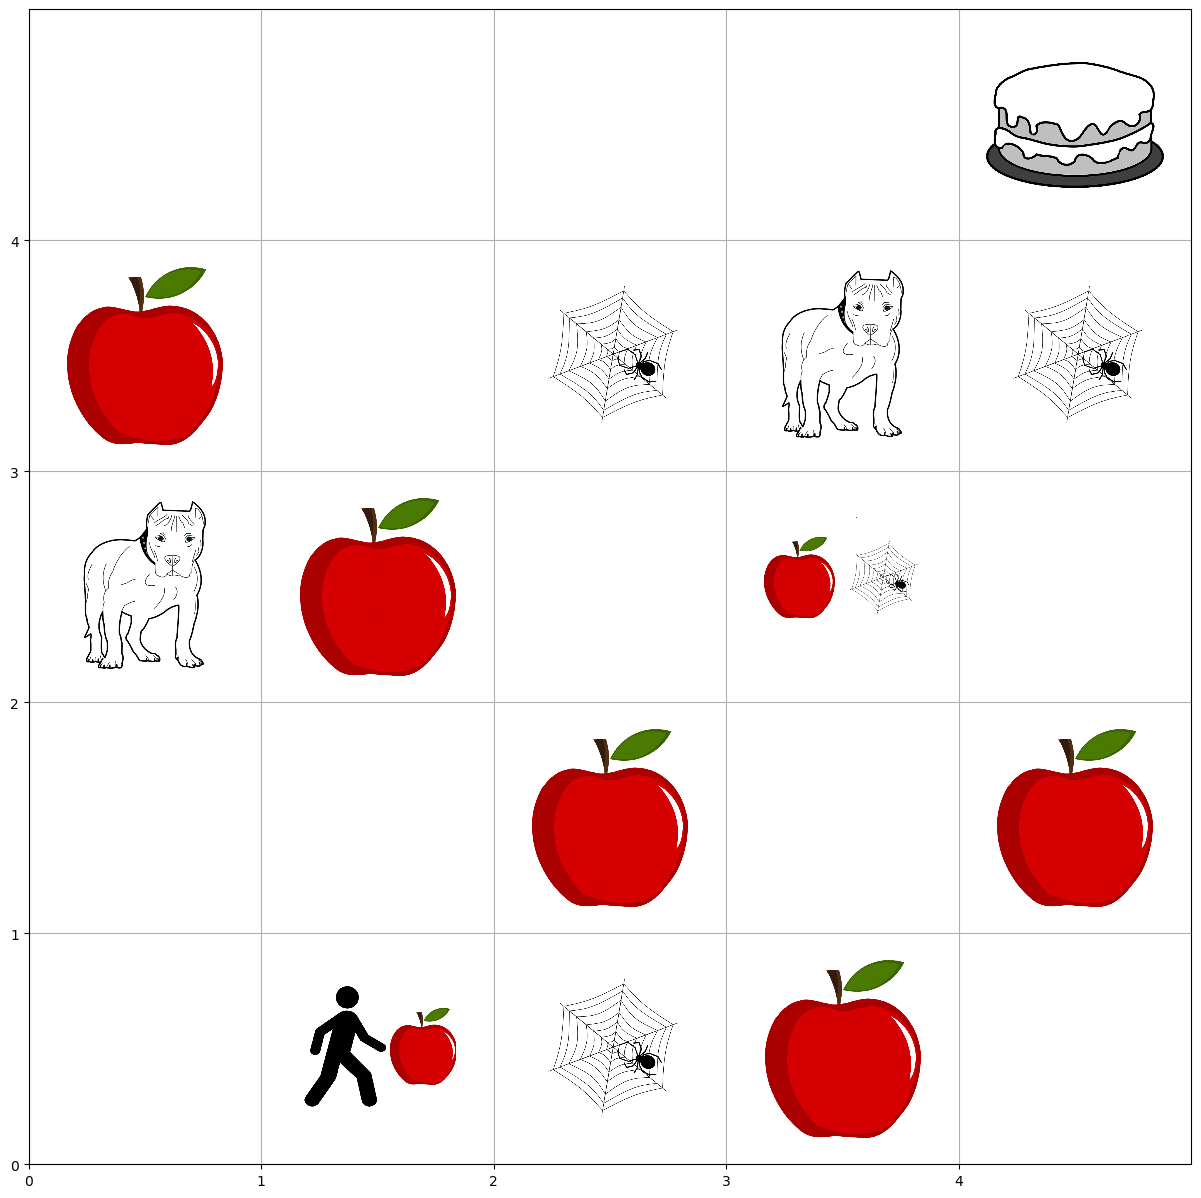

Episode 2:


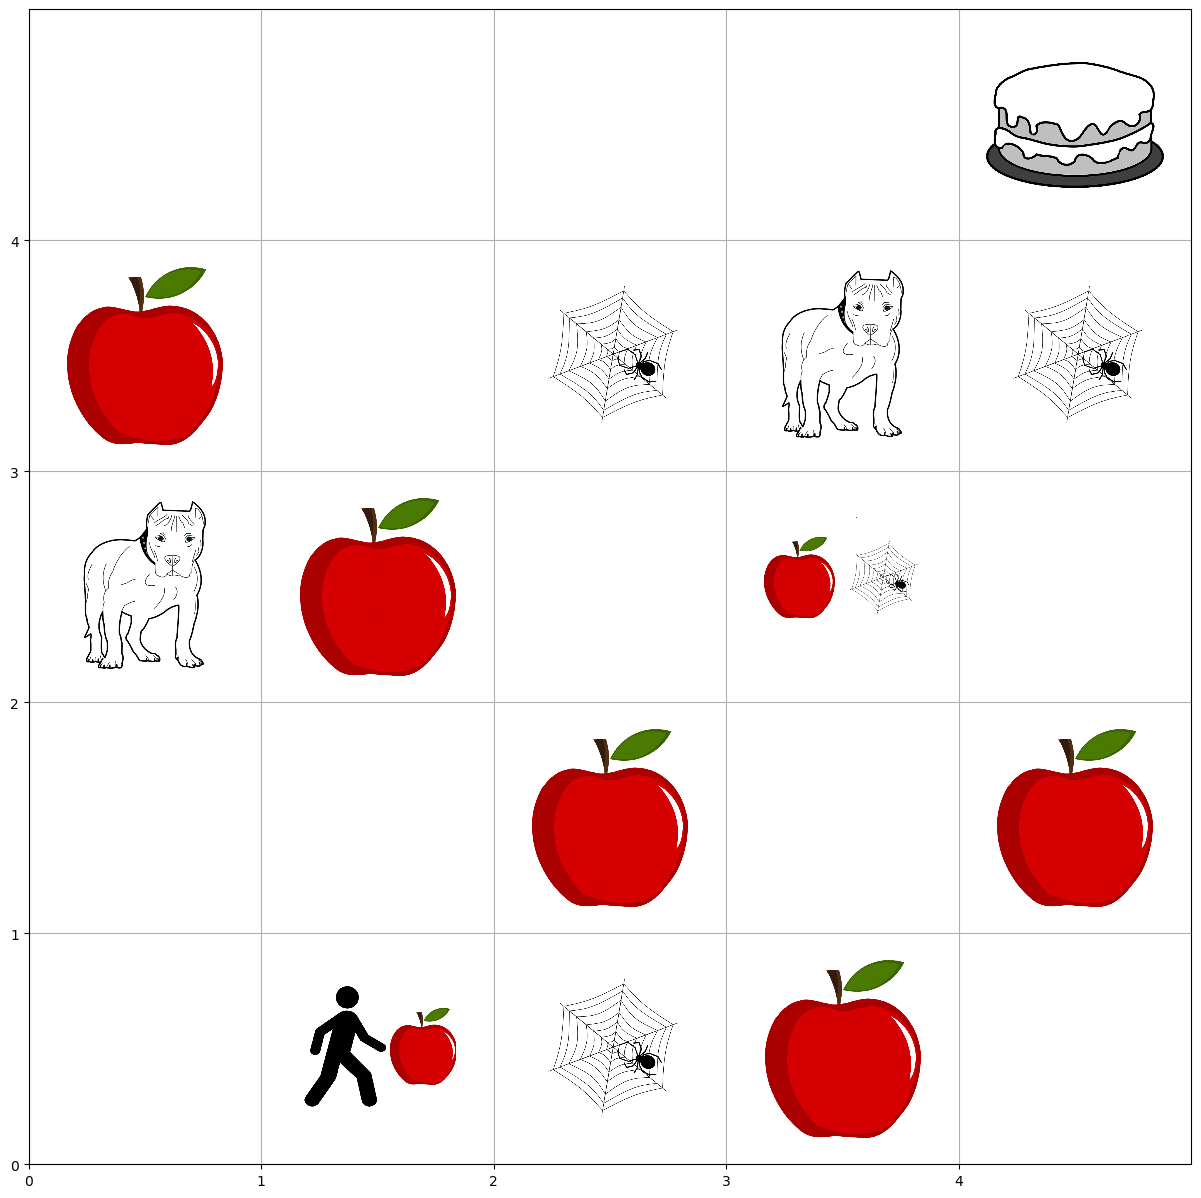

Episode 3:


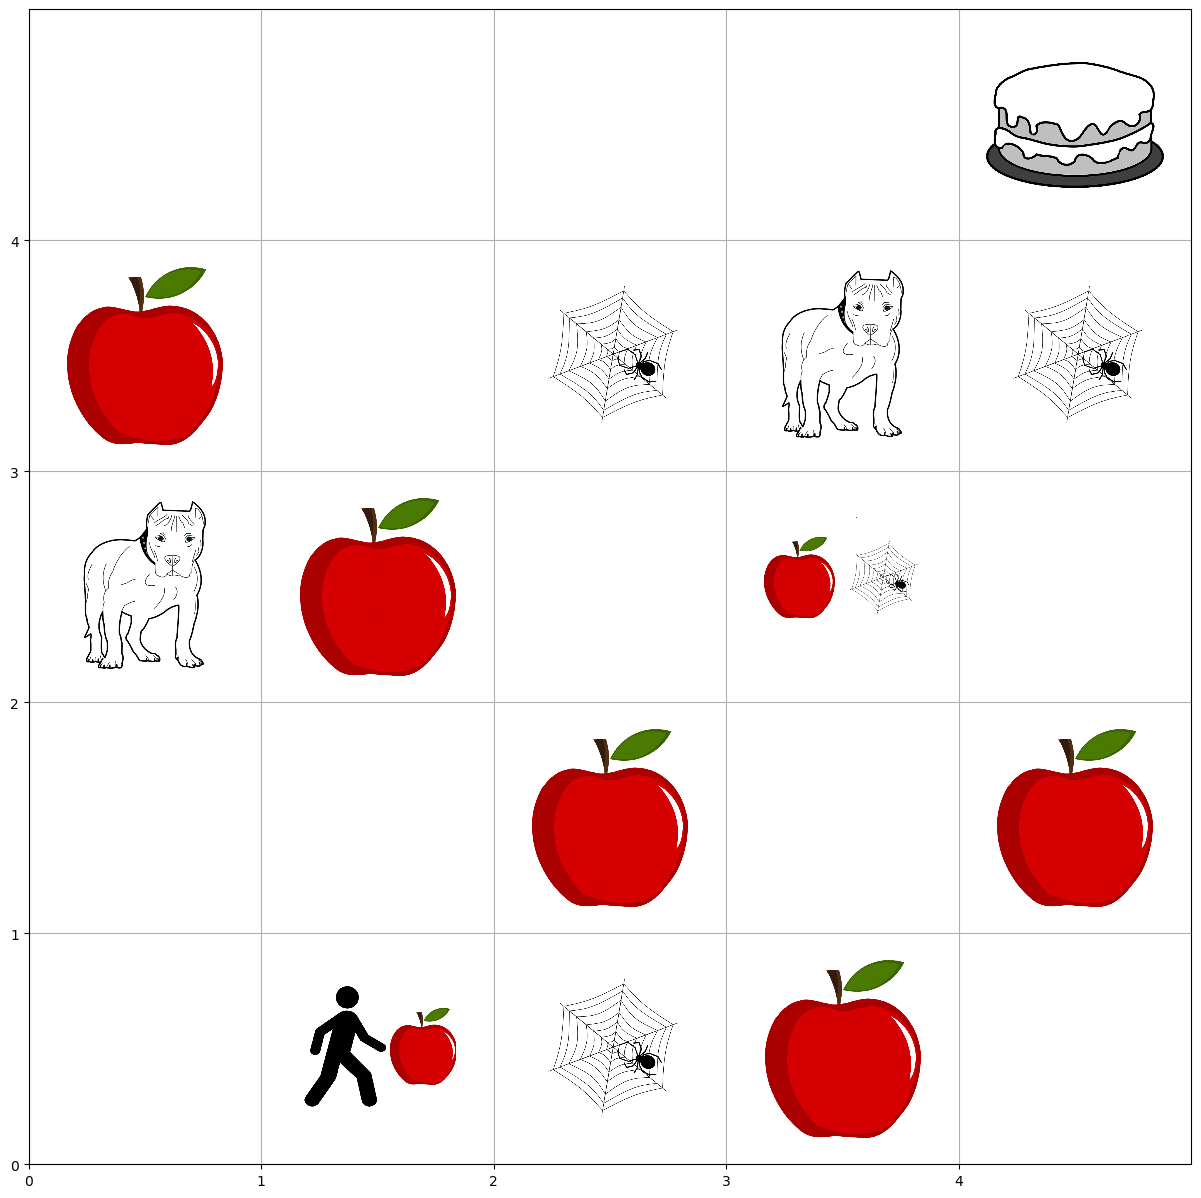

Episode 4:


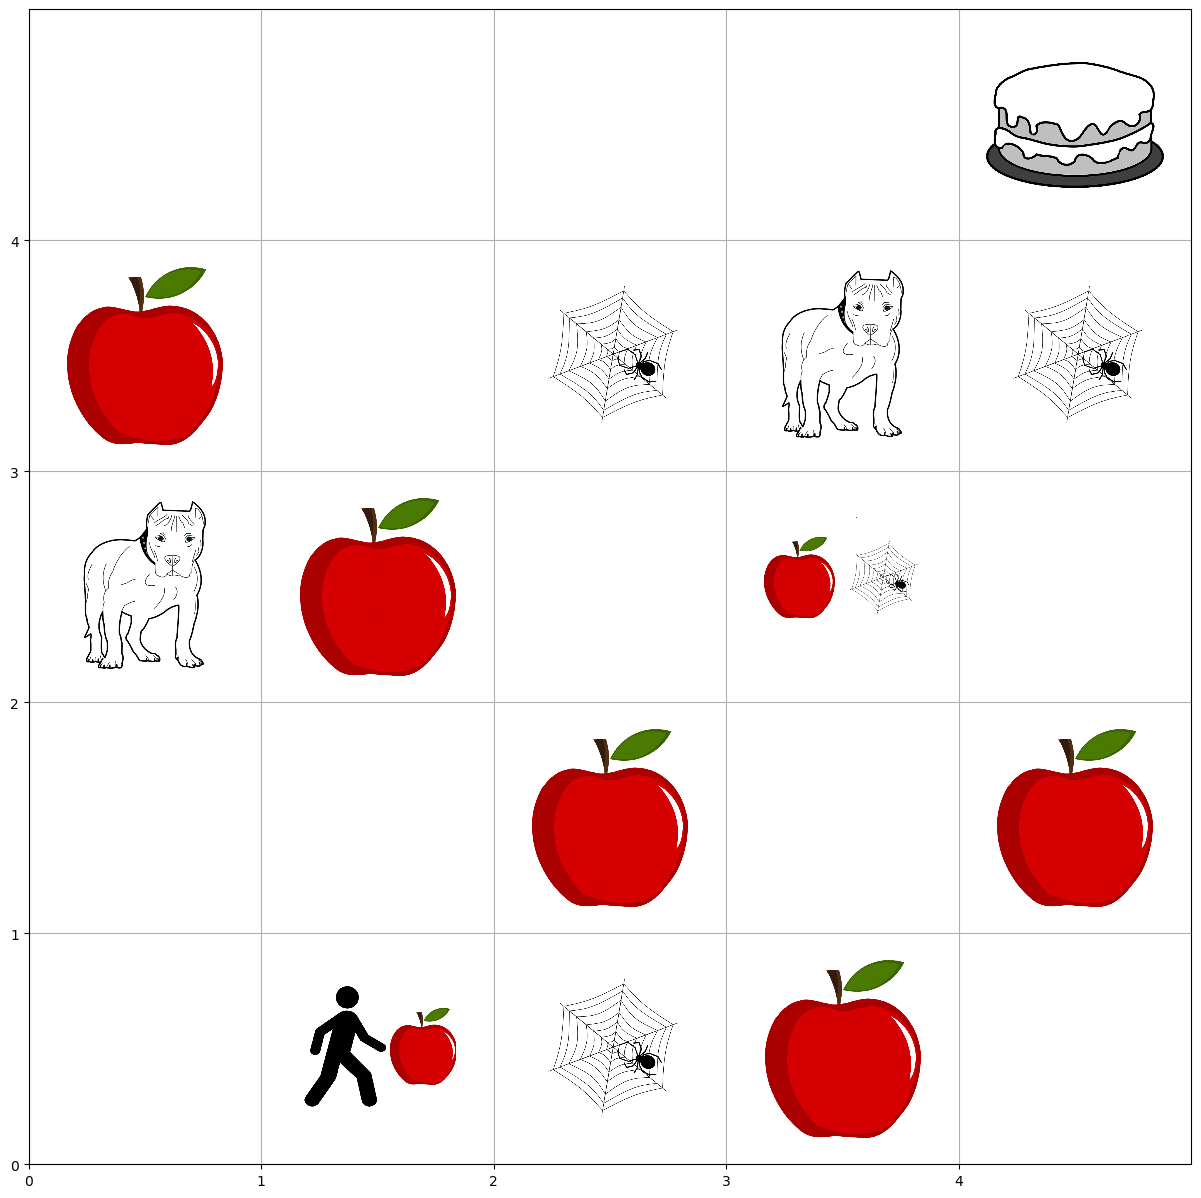

Episode 5:


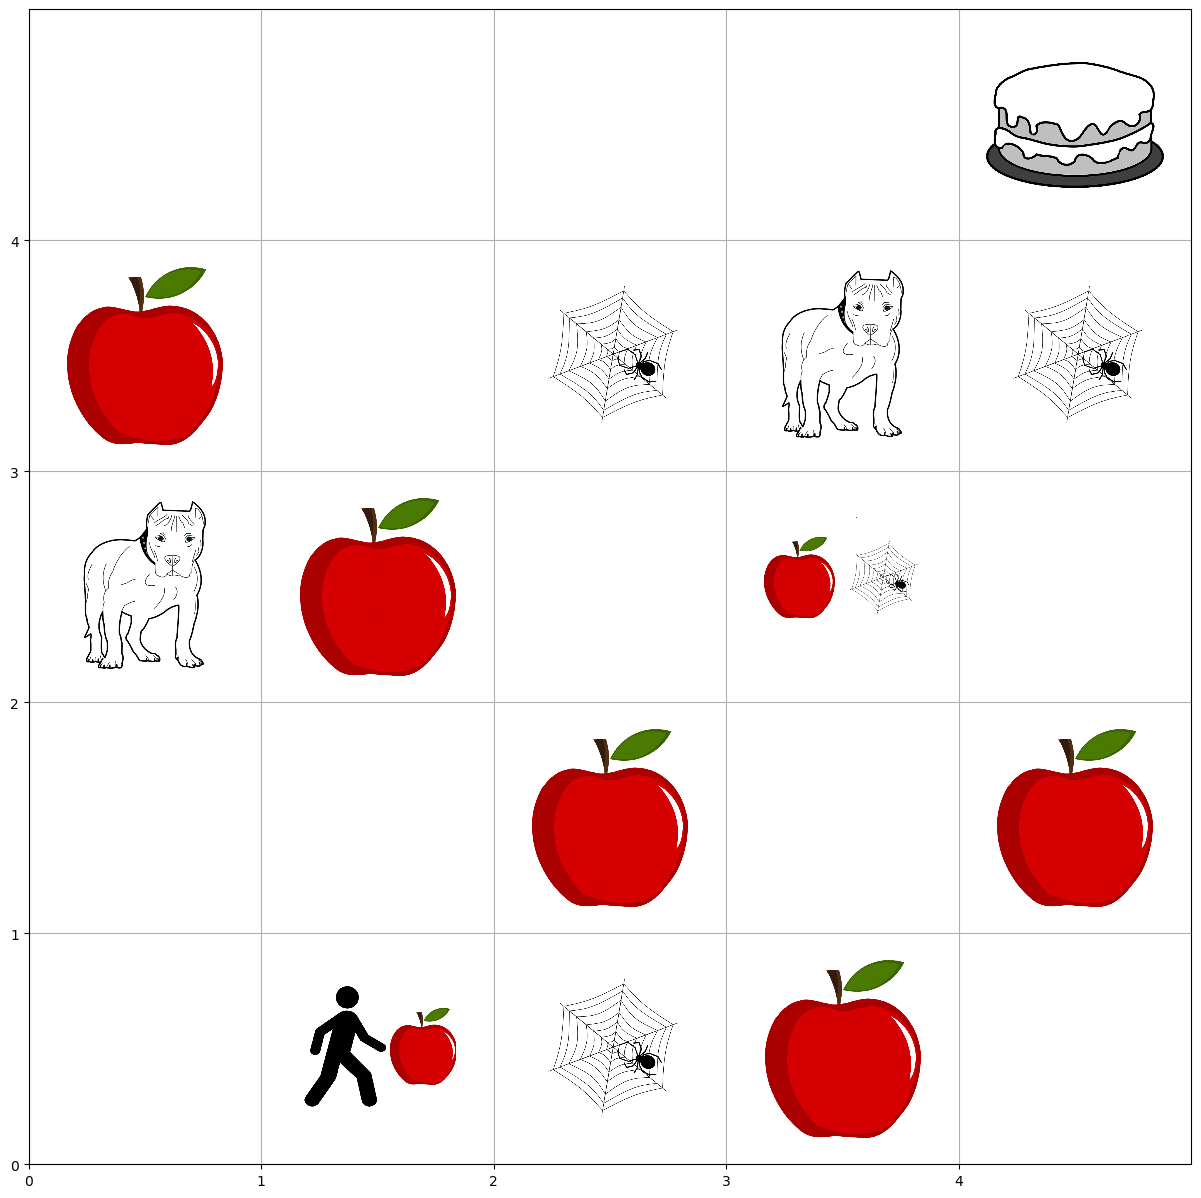

Episode 6:


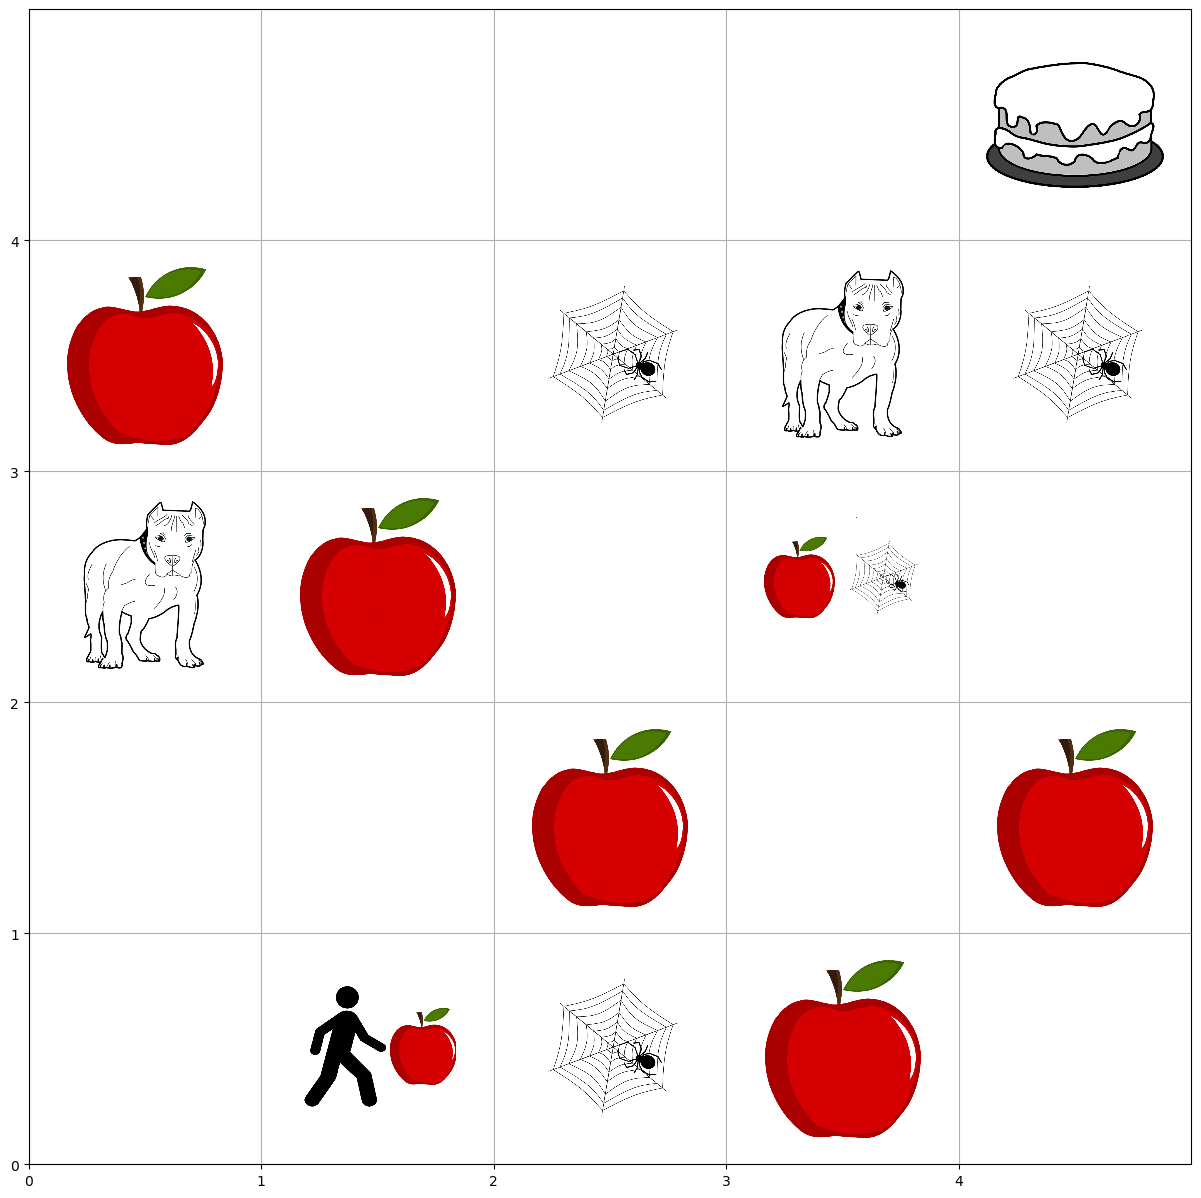

Episode 7:


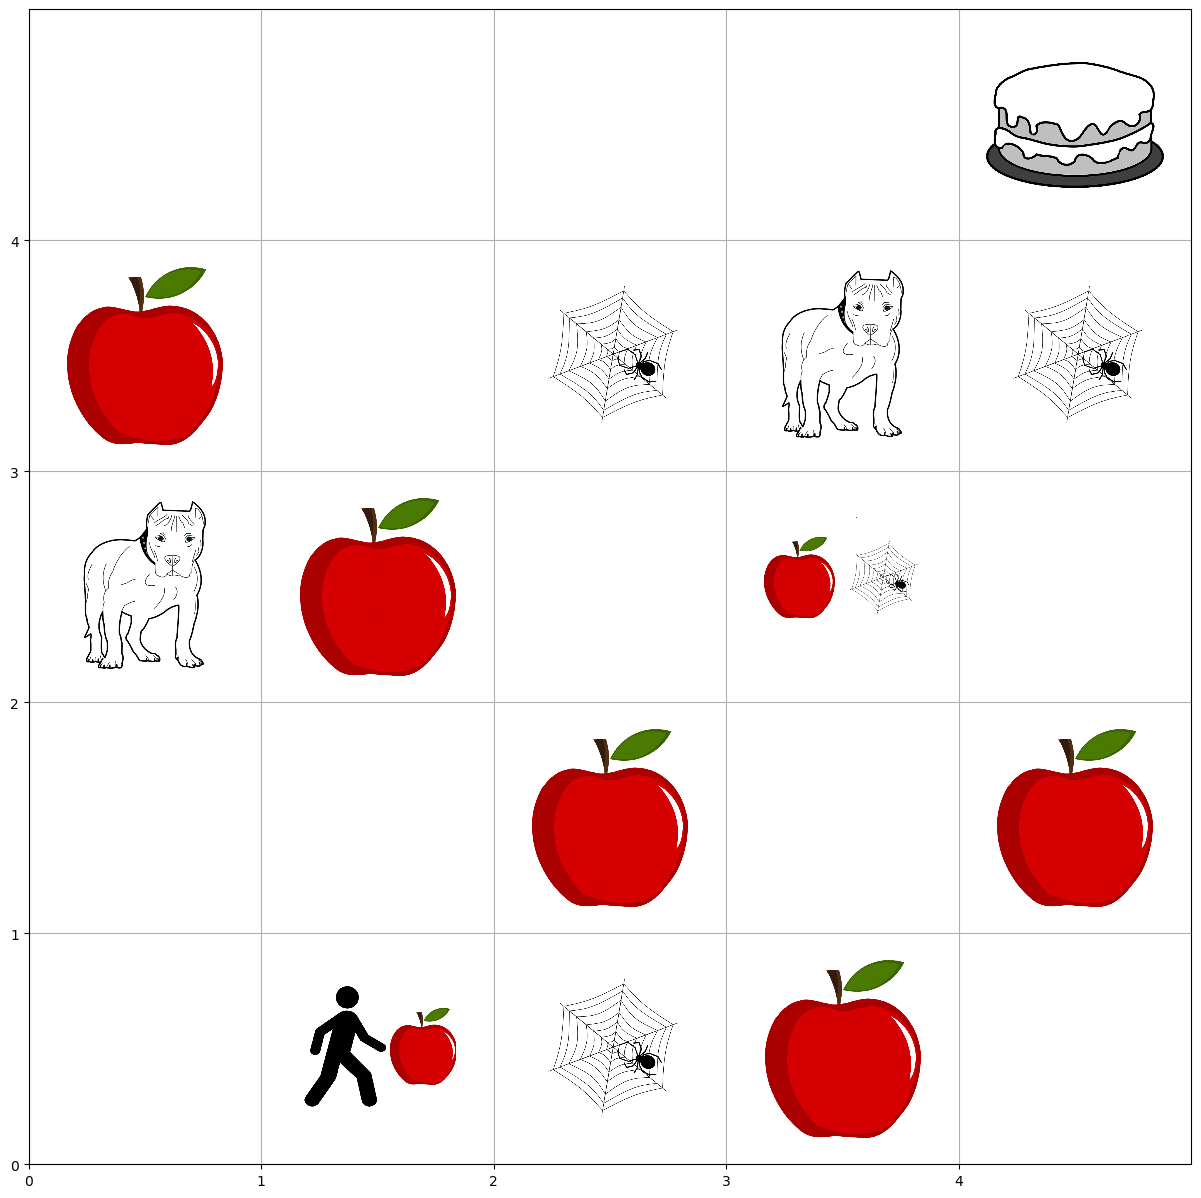

Episode 8:


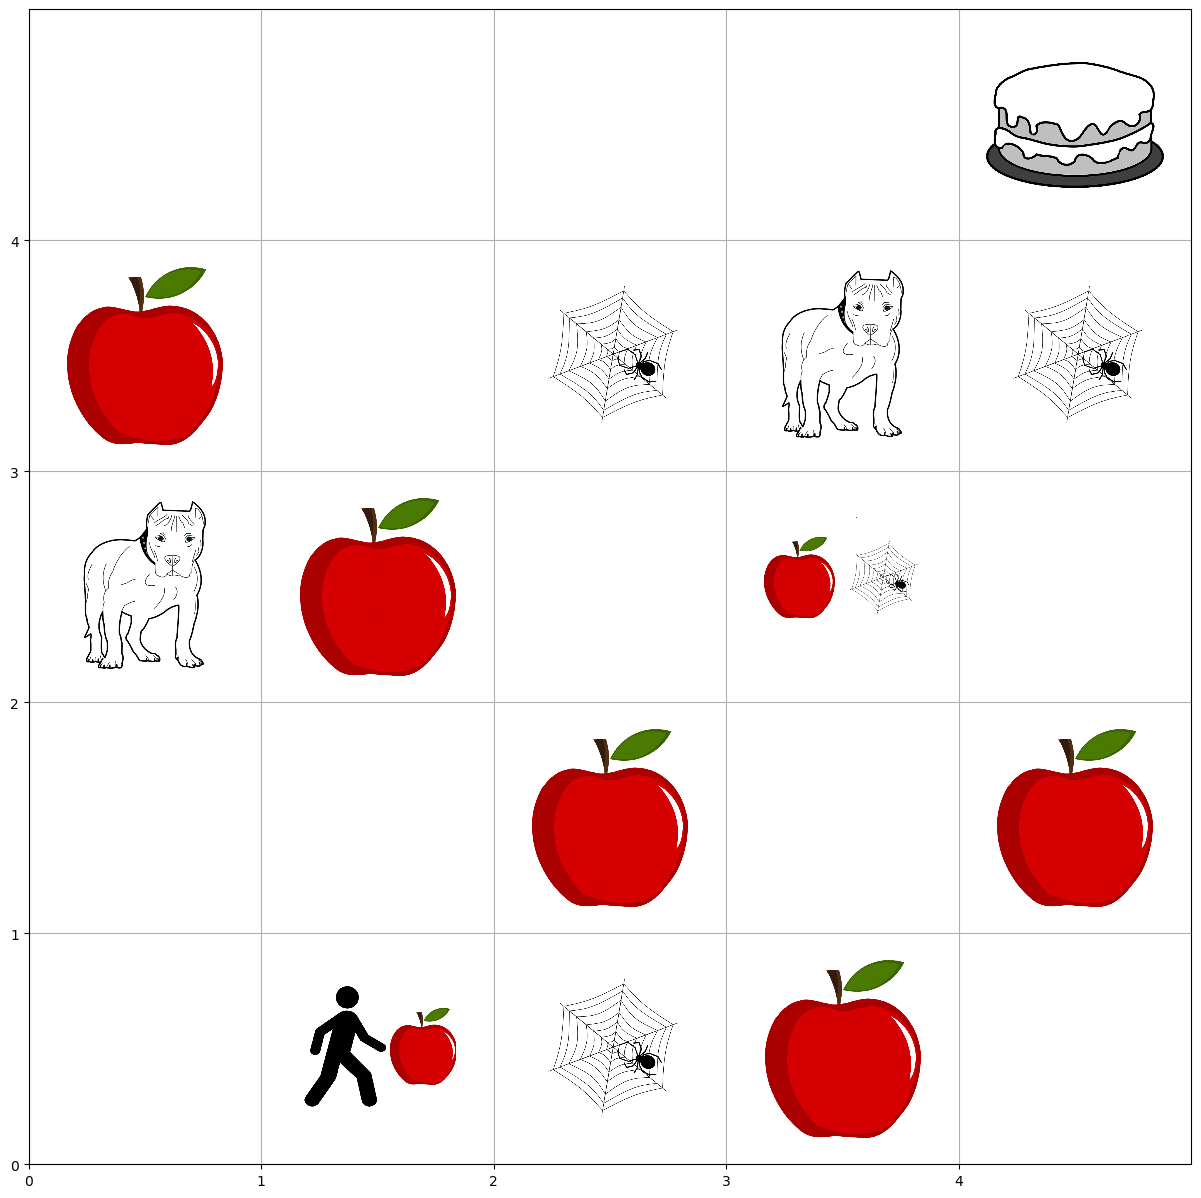

Episode 9:


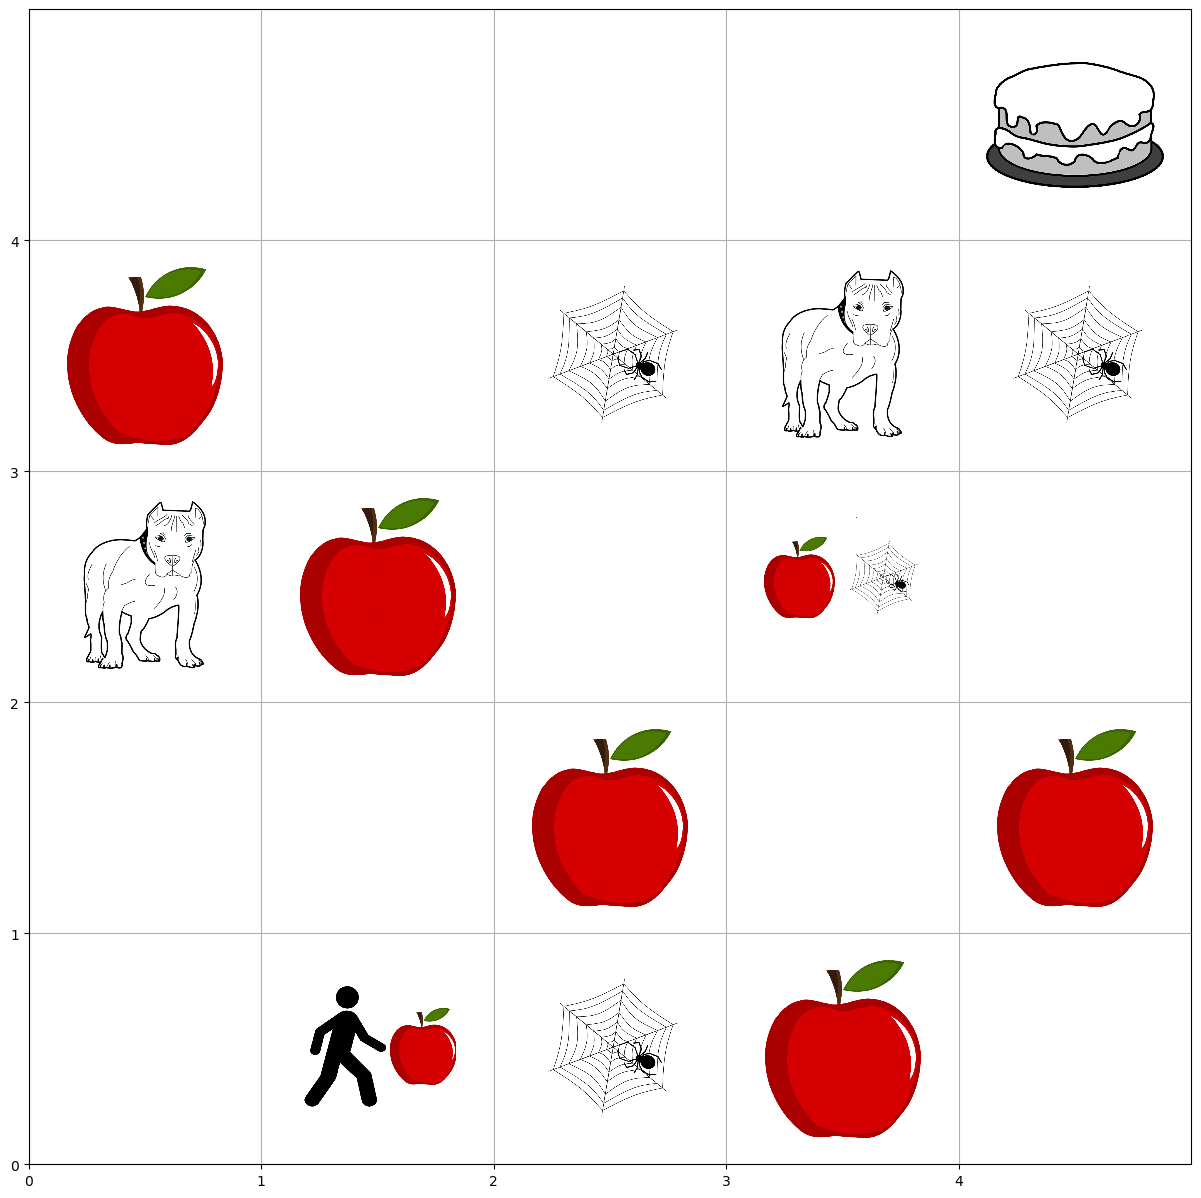

In [140]:
# Greedy policy evaluation
greedy_reward_history = evaluate_greedy_policy(hungryman_world, Q, 10, max_steps, plot=True)

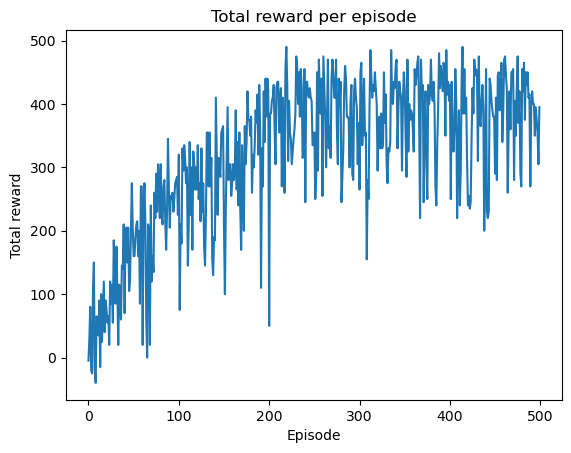

In [170]:
# Plot the total reward per episode
def plot_reward(reward_history):
    plt.figure()
    plt.plot(range(episodes), reward_history)
    plt.title("Total reward per episode")
    plt.xlabel("Episode")
    plt.ylabel("Total reward")
    plt.show()
plot_reward(reward_history)

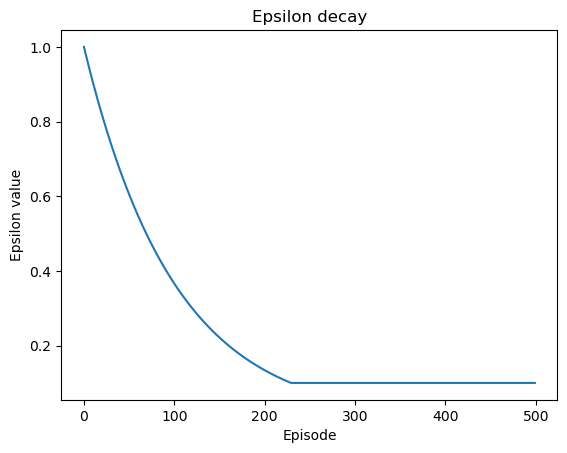

In [172]:
# Plot epsilon decay
def plot_epsilon_decay(episodes):
    plt.figure()
    plt.plot(range(episodes), epsilon_history)
    plt.title("Epsilon decay")
    plt.xlabel("Episode")
    plt.ylabel("Epsilon value")
    plt.show()
plot_epsilon_decay(episodes)

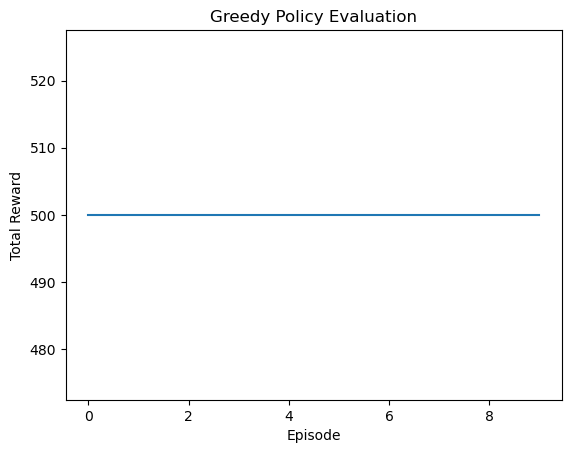

In [143]:
# Greedy policy evaluation
def plot_greedy_evaluation(greedy_reward_history):
    plt.figure()
    plt.plot(greedy_reward_history)
    plt.title("Greedy Policy Evaluation")
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.show()
plot_greedy_evaluation(greedy_reward_history)

### Hyperparameter tuning - alpha(update size)
- 0.3
- 0.7
- 0.85

Initial Q-Table:
(0, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(0, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(0, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(0, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(0, 4) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 4) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 4) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 4) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 4) {0: 0, 1: 0, 2: 0, 3: 0}

Trained Q-Table:
(0, 0) {0: 25.77027622493415, 1: -2.7065314937199613e-05, 2: -0.00037591515618967447, 3: -1.7513765949459704e-05}
(0, 1) {0: 22.12605039537413, 1: -0.015708367804192

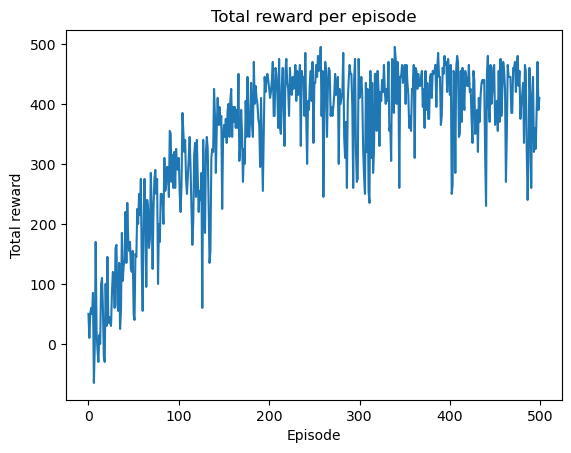

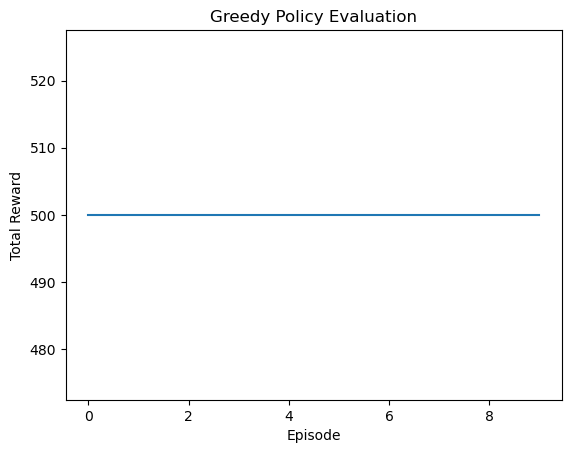

In [159]:
alpha = 0.3
Q, reward_history, epsilon_history = sarsa(hungryman_world, episodes, alpha, discount_factor, epsilon, epsilon_decay, epsilon_min,max_steps)
greedy_reward_history = evaluate_greedy_policy(hungryman_world, Q, 10, max_steps)
plot_reward(reward_history)
plot_greedy_evaluation(greedy_reward_history)

Initial Q-Table:
(0, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(0, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(0, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(0, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(0, 4) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 4) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 4) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 4) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 4) {0: 0, 1: 0, 2: 0, 3: 0}

Trained Q-Table:
(0, 0) {0: 15.870789128636858, 1: -3.4052029451035746e-09, 2: -0.00018257904990281825, 3: -2.9652197321044107e-12}
(0, 1) {0: 1.8033901154355139, 1: -0.0172126897952

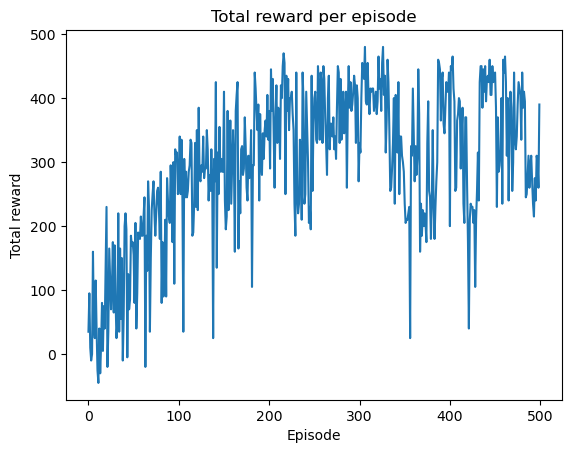

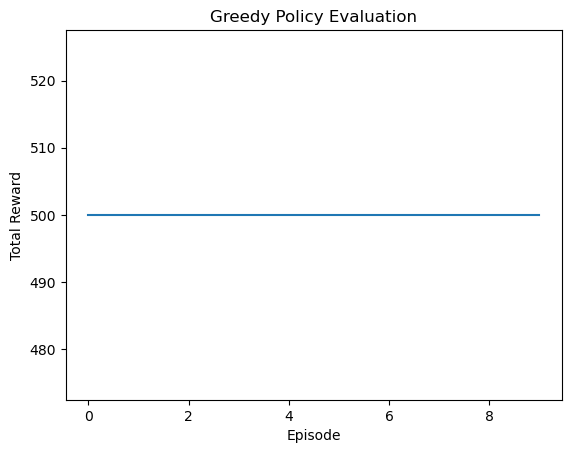

In [162]:
alpha = 0.7
Q, reward_history, epsilon_history = sarsa(hungryman_world, episodes, alpha, discount_factor, epsilon, epsilon_decay, epsilon_min,max_steps)
greedy_reward_history = evaluate_greedy_policy(hungryman_world, Q, 10, max_steps)
plot_reward(reward_history)
plot_greedy_evaluation(greedy_reward_history)

Initial Q-Table:
(0, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(0, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(0, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(0, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(0, 4) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 4) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 4) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 4) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 4) {0: 0, 1: 0, 2: 0, 3: 0}

Trained Q-Table:
(0, 0) {0: 5.834265804331556, 1: -6.670685765098586e-13, 2: 0.06955606724907454, 3: -2.993096884105782e-22}
(0, 1) {0: 3.194695128179056, 1: -0.00227761370525467, 2:

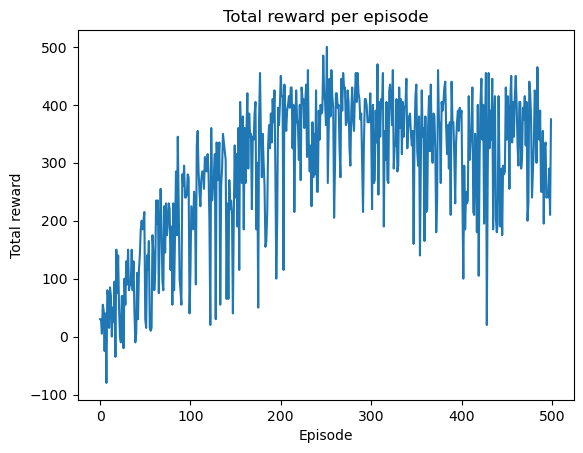

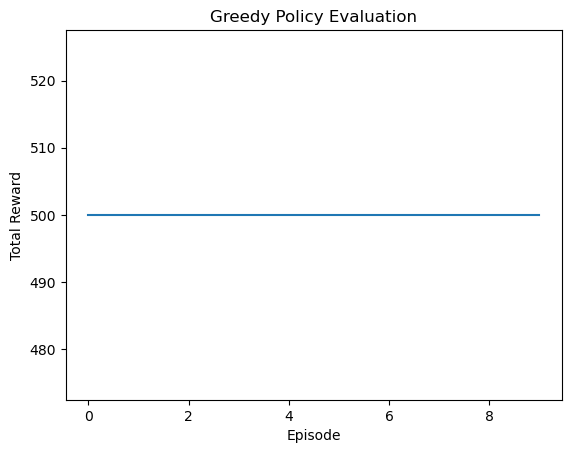

In [163]:
alpha = 0.85
Q, reward_history, epsilon_history = sarsa(hungryman_world, episodes, alpha, discount_factor, epsilon, epsilon_decay, epsilon_min,max_steps)
greedy_reward_history = evaluate_greedy_policy(hungryman_world, Q, 10, max_steps)
plot_reward(reward_history)
plot_greedy_evaluation(greedy_reward_history)

Result description
- The larger alpha value, the faster the learning speed.
- If the alpha value is too high, the stablity of learning may decrease.
- The original value 0.5 seems appropriate.

### Hyperparameter tuning - discount factor
- 0.99
- 0.95
- 0.8

In [164]:
alpha = 0.5

Initial Q-Table:
(0, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(0, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(0, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(0, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(0, 4) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 4) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 4) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 4) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 4) {0: 0, 1: 0, 2: 0, 3: 0}

Trained Q-Table:
(0, 0) {0: 53.761129561088254, 1: -2.2245061009702305e-11, 2: -9.692626087664238e-05, 3: -1.4285379615361057e-09}
(0, 1) {0: 15.82024980673425, 1: -0.000379612598401

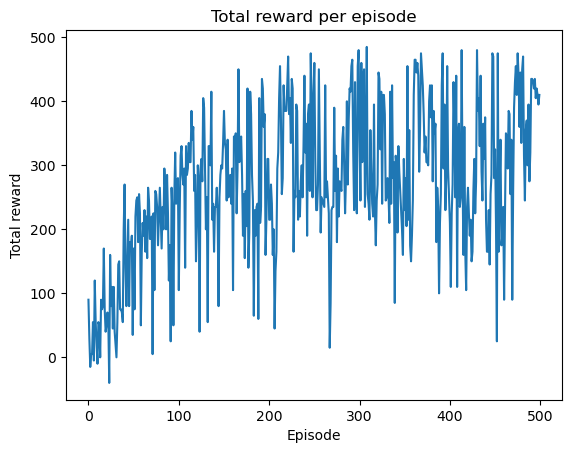

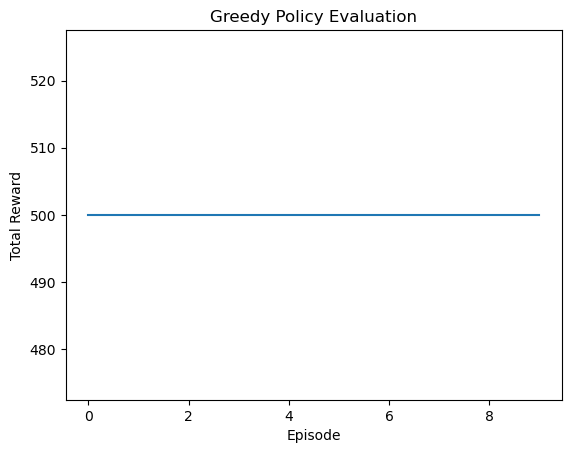

In [177]:
discount_factor = 0.99
Q, reward_history, epsilon_history = sarsa(hungryman_world, episodes, alpha, discount_factor, epsilon, epsilon_decay, epsilon_min,max_steps)
greedy_reward_history = evaluate_greedy_policy(hungryman_world, Q, 10, max_steps)
plot_reward(reward_history)
plot_greedy_evaluation(greedy_reward_history)

Initial Q-Table:
(0, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(0, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(0, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(0, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(0, 4) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 4) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 4) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 4) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 4) {0: 0, 1: 0, 2: 0, 3: 0}

Trained Q-Table:
(0, 0) {0: 22.390296873381928, 1: -6.465596461381636e-09, 2: -2.9232765680475903e-06, 3: -2.8019282074678034e-09}
(0, 1) {0: 32.236955940055246, 1: -0.00676590845353

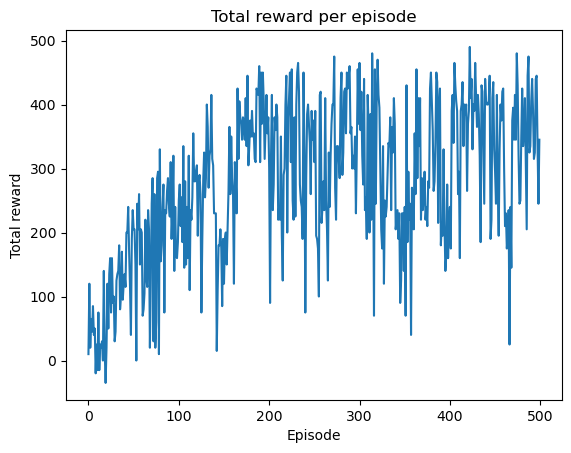

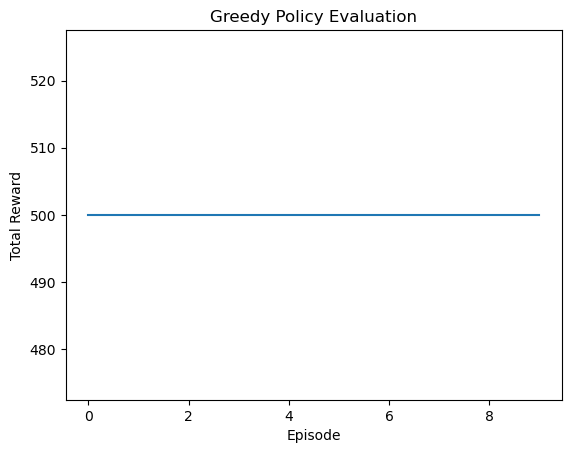

In [178]:
discount_factor = 0.95
Q, reward_history, epsilon_history = sarsa(hungryman_world, episodes, alpha, discount_factor, epsilon, epsilon_decay, epsilon_min,max_steps)
greedy_reward_history = evaluate_greedy_policy(hungryman_world, Q, 10, max_steps)
plot_reward(reward_history)
plot_greedy_evaluation(greedy_reward_history)

Initial Q-Table:
(0, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(0, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(0, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(0, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(0, 4) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 4) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 4) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 4) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 4) {0: 0, 1: 0, 2: 0, 3: 0}

Trained Q-Table:
(0, 0) {0: 15.712335944770112, 1: -0.0001140034673183012, 2: -0.0002682434445620233, 3: -7.157717437408914e-13}
(0, 1) {0: 9.128861096073955, 1: -1.5911351962692861,

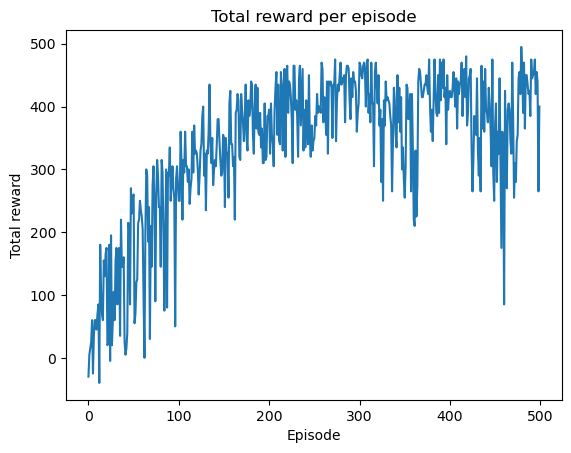

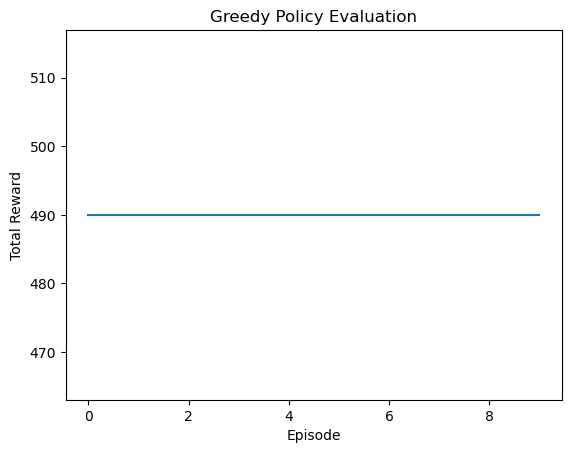

In [181]:
discount_factor = 0.8
Q, reward_history, epsilon_history = sarsa(hungryman_world, episodes, alpha, discount_factor, epsilon, epsilon_decay, epsilon_min,max_steps)
greedy_reward_history = evaluate_greedy_policy(hungryman_world, Q, 10, max_steps)
plot_reward(reward_history)
plot_greedy_evaluation(greedy_reward_history)

Result description
- The larger the discount factor value, the slower the learning speed becomes.
- If the alpha value is too small, the probability of achieving learning optimization may decrease.
- Since the environment is simple, a discount factor value of 0.8 appears appropriate.

### The most efficient hyperparameter values
- alpha 0.5
- discount factor 0.8

In [182]:
hungryman_world = HungrymanWorldEnvironment(environment_type='deterministic')
episodes = 500
alpha = 0.5
discount_factor = 0.8
epsilon = 1.0
epsilon_decay = 0.99
epsilon_min = 0.1
max_steps = 100

In [183]:
Q, reward_history, epsilon_history = sarsa(hungryman_world, episodes, alpha, discount_factor, epsilon, epsilon_decay, epsilon_min,max_steps)
greedy_reward_history = evaluate_greedy_policy(hungryman_world, Q, 10, max_steps)

Initial Q-Table:
(0, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(0, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(0, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(0, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(0, 4) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(1, 4) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(2, 4) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(3, 4) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 0) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 1) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 2) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 3) {0: 0, 1: 0, 2: 0, 3: 0}
(4, 4) {0: 0, 1: 0, 2: 0, 3: 0}

Trained Q-Table:
(0, 0) {0: 12.540769302581587, 1: -4.921690182594583e-06, 2: -0.5227003275700554, 3: -2.42143477766901e-08}
(0, 1) {0: 10.073615319468374, 1: -0.00035454180103229355

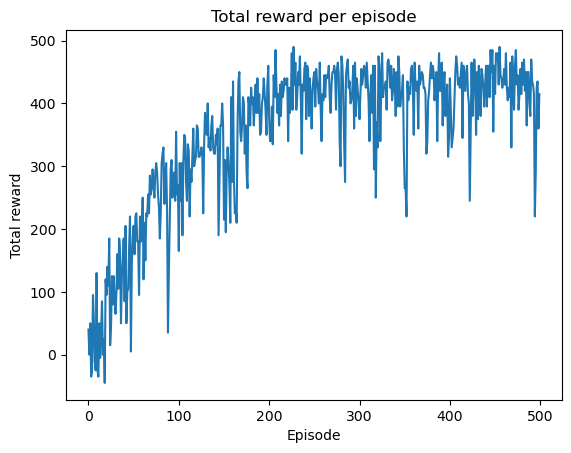

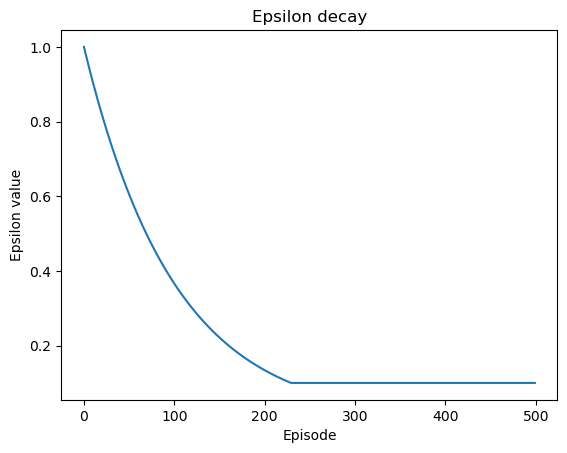

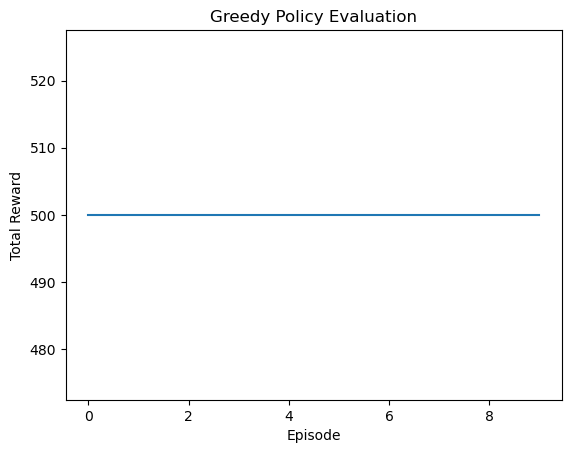

In [184]:
plot_reward(reward_history)
plot_epsilon_decay(episodes)
plot_greedy_evaluation(greedy_reward_history)

### References
- hungryman_world.py from 'visualizing_rl_environments_and_representing_the_results (2)'
- images: 'stick-man-walking-hiking', 'dog-animal-pet-canine-bull-pit', 'apple-fruit-red-healthy-diet', 'spider-spiderweb', 'cake-birthday-sugar-icing-party' Pixabay
- https://gymnasium.farama.org/api/spaces/
- Assignment 3 part 1
- https://www.geeksforgeeks.org/sarsa-reinforcement-learning/
- https://www.kaggle.com/code/khusheekapoor/sarsa-and-q-learning
- https://medium.com/analytics-vidhya/q-learning-expected-sarsa-and-comparison-of-td-learning-algorithms-e4612064de97